336 frames in D:\dev\jupyter_book\echomimic_v2\assets\halfbody_demo\pose\01
keys: ['bodies', 'hands', 'hands_score', 'faces', 'faces_score', 'num', 'draw_pose_params']
draw_pose_params: [768, 768, 0, 768, 0, 768]


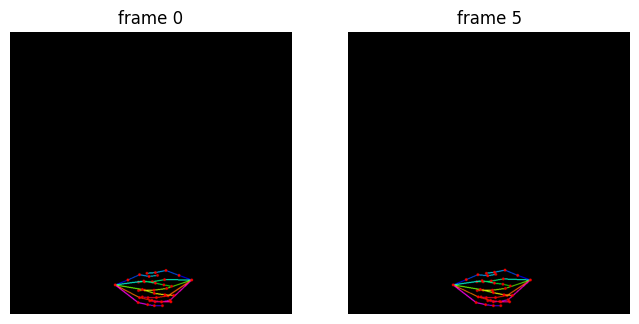

poses_tensor shape: (1, 3, 336, 768, 768)


In [1]:
# === Minimal EM2 pose .npy explorer (same render path as infer.py) ===
from pathlib import Path
import sys, os, re, numpy as np, torch, matplotlib.pyplot as plt

# 0) Make imports work whether you run from repo root or experiments/
root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))
from src.utils.dwpose_util import draw_pose_select_v2  # renderer used by infer.py

# 1) Config
W = H = 768
pose_folder = root / "assets/halfbody_demo" / "pose" / "01"

# 2) List frames (natural sort: 0,1,2,...10)
nsort = lambda xs: sorted(xs, key=lambda s: [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", s)])
files = nsort([f for f in os.listdir(pose_folder) if f.endswith(".npy")])
print(f"{len(files)} frames in {pose_folder}")

# 3) Peek one dict
sample = np.load(pose_folder / files[0], allow_pickle=True).item()
print("keys:", list(sample))
print("draw_pose_params:", sample.get("draw_pose_params"))

# 4) Render helper (exactly like infer.py does, then paste into full canvas)
def render_full(pose_dict, W=768, H=768, ref_w=800):
    imh, imw, rb, re, cb, ce = pose_dict["draw_pose_params"]
    im_chw = draw_pose_select_v2(pose_dict, imh, imw, ref_w)     # CHW uint8
    canvas = np.zeros((H, W, 3), np.uint8)
    canvas[rb:re, cb:ce] = im_chw.transpose(1, 2, 0)             # HWC
    return canvas

# 5) Show two frames
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
for k, i in enumerate([0, min(5, len(files)-1)]):
    pose_i = np.load(pose_folder / files[i], allow_pickle=True).item()
    ax[k].imshow(render_full(pose_i, W, H)); ax[k].set_title(f"frame {i}"); ax[k].axis("off")
plt.show()

# 6) Build tensor [1, 3, T, H, W] for the pipeline
poses = []
for name in files:
    pose = np.load(pose_folder / name, allow_pickle=True).item()
    img = render_full(pose, W, H)                                # HWC uint8
    poses.append(torch.from_numpy(img).permute(2,0,1).float()/255.)
poses_tensor = torch.stack(poses, dim=1).unsqueeze(0)

print("poses_tensor shape:", tuple(poses_tensor.shape))  # -> (1, 3, T, H, W)


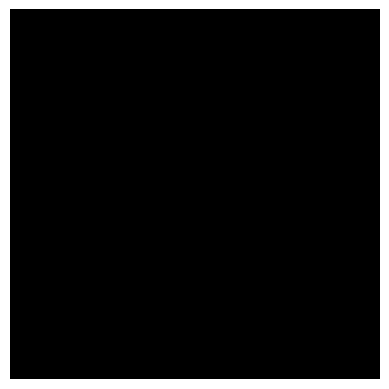

In [8]:
width = 768
height = 768
tgt_musk = np.zeros((height, width, 3)).astype('uint8')
plt.imshow(tgt_musk)
plt.axis("off")   # Hide axis
plt.show()

In [5]:
tgt_musk_path = os.path.join(root / "assets/halfbody_demo" / "pose" / "01", "{}.npy".format(0)) 
detected_pose = np.load(tgt_musk_path, allow_pickle=True).tolist()
imh_new, imw_new, rb, re, cb, ce = detected_pose['draw_pose_params']
imh_new, imw_new, rb, re, cb, ce


(768, 768, 0, 768, 0, 768)

(3, 768, 768)
(768, 768, 3)


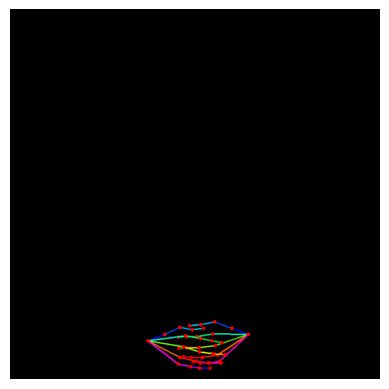

In [24]:
im = draw_pose_select_v2(detected_pose, imh_new, imw_new, ref_w=800)
print(im.shape)
im = np.transpose(np.array(im), (1, 2, 0))  # reorders it to (H, W, C), which is what matplotlib.pyplot.imshow expects.
print(im.shape)
plt.imshow(im)
plt.axis("off")
plt.show()

In [ ]:
im = draw_pose_select_v2(detected_pose, imh_new, imw_new, ref_w=800)
im = np.transpose(np.array(im),(1, 2, 0))
tgt_musk[rb:re,cb:ce,:] = im
